<a href="https://colab.research.google.com/github/Benguerine/ai-notebook/blob/main/Auto_Encoders_lab1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Auto-Encoder first lab**

![Time to coding](https://media.giphy.com/media/Sm9AfJRiZofjlrkAAl/giphy.gif?cid=790b7611b0579586f9447d67925f1f282f79580b3501d1ed&ep=v1_user_favorites&rid=giphy.gif&ct=g)

The cat is coding now, what is your issue?

In [1]:
import datetime
print(f"Last edit notebook: {datetime.datetime.now()}")

Last edit notebook: 2026-04-04 20:45:33.697013


In [2]:
import tensorflow as tf
import matplotlib.pyplot as plt
import numpy as np
import os

In [3]:
tf.random.set_seed(42)
np.random.seed(42)

In [4]:
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid')

In [5]:
def load_and_preprocess_data():
    print("Loading CIFAR-10 dataset...")
    (x_train, _), (x_test, _) = tf.keras.datasets.cifar10.load_data()

    # Normalize to [0, 1]
    x_train = x_train.astype('float32') / 255.0
    x_test = x_test.astype('float32') / 255.0

    print(f"Train shape: {x_train.shape} | Test shape: {x_test.shape}")
    return x_train, x_test

x_train, x_test = load_and_preprocess_data()

Loading CIFAR-10 dataset...
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step
Train shape: (50000, 32, 32, 3) | Test shape: (10000, 32, 32, 3)


In [6]:
def corrupt_images(images, corruption_type='mask', missing_fraction=0.3):
    """
    Creates corrupted versions of images.
    - 'mask': Applies random rectangular black masks (ideal for inpainting)
    - 'dropout': Randomly sets pixels to 0 (simulates sensor noise/transmission loss)
    """
    corrupted = np.copy(images)
    n, h, w, c = images.shape

    for i in range(n):
        if corruption_type == 'mask':
            mh = max(1, int(h * missing_fraction * np.random.uniform(0.7, 1.3)))
            mw = max(1, int(w * missing_fraction * np.random.uniform(0.7, 1.3)))
            sh = np.random.randint(0, h - mh)
            sw = np.random.randint(0, w - mw)
            corrupted[i, sh:sh+mh, sw:sw+mw, :] = 0.0

        elif corruption_type == 'dropout':
            mask = np.random.rand(h, w, c) < (1 - missing_fraction)
            corrupted[i] = images[i] * mask

    return corrupted

print("Applying corruption to train/test sets...")
x_train_corrupted = corrupt_images(x_train, corruption_type='mask', missing_fraction=0.35)
x_test_corrupted = corrupt_images(x_test, corruption_type='mask', missing_fraction=0.35)

Applying corruption to train/test sets...


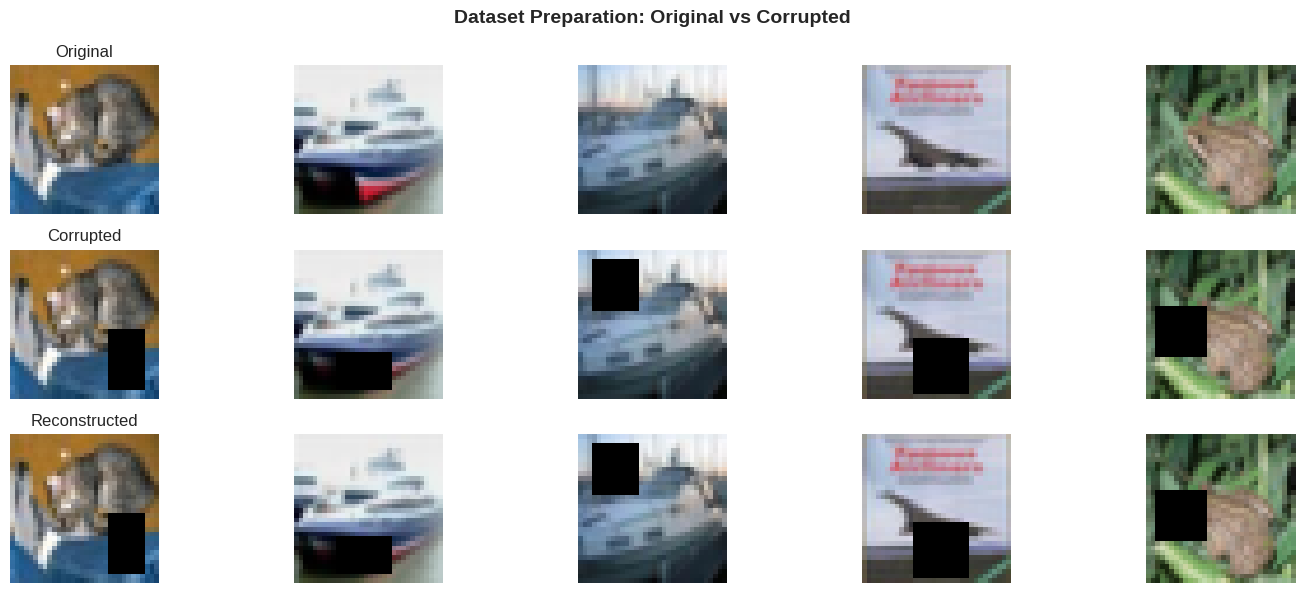

In [7]:
def plot_comparison(original, corrupted, reconstructed, n_samples=5, title="Reconstruction Results"):
    plt.figure(figsize=(15, 6))
    for i in range(n_samples):
        # Original
        plt.subplot(3, n_samples, i + 1)
        plt.imshow(original[i])
        plt.axis('off')
        if i == 0: plt.title('Original', fontsize=12)

        # Corrupted
        plt.subplot(3, n_samples, i + 1 + n_samples)
        plt.imshow(corrupted[i])
        plt.axis('off')
        if i == 0: plt.title('Corrupted', fontsize=12)

        # Reconstructed
        plt.subplot(3, n_samples, i + 1 + 2*n_samples)
        plt.imshow(reconstructed[i])
        plt.axis('off')
        if i == 0: plt.title('Reconstructed', fontsize=12)

    plt.suptitle(title, fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Quick sanity check before training
plot_comparison(x_test[:5], x_test_corrupted[:5], x_test_corrupted[:5],
                title="Dataset Preparation: Original vs Corrupted")

## **Architecture of the auto-encoder model of this lab**

![autoencoder components](https://miro.medium.com/v2/format:webp/1*nocBSRodPFu3XD5UXfTwbw.png)

In [8]:
def build_conv_autoencoder(input_shape=(32, 32, 3)):
    inputs = tf.keras.layers.Input(shape=input_shape)

    # Encoder
    x = tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same')(inputs)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D((2,2), padding='same')(x)  # 16x16

    x = tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.MaxPooling2D((2,2), padding='same')(x)  # 8x8

    # Latent Representation (Bottleneck)
    latent = tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same')(x)
    latent = tf.keras.layers.BatchNormalization()(latent)
    latent = tf.keras.layers.MaxPooling2D((2,2), padding='same')(latent)  # 4x4x128

    # Decoder
    x = tf.keras.layers.Conv2D(128, (3,3), activation='relu', padding='same')(latent)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.UpSampling2D((2,2))(x)  # 8x8

    x = tf.keras.layers.Conv2D(64, (3,3), activation='relu', padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.UpSampling2D((2,2))(x)  # 16x16

    x = tf.keras.layers.Conv2D(32, (3,3), activation='relu', padding='same')(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.UpSampling2D((2,2))(x)  # 32x32

    # Output layer (sigmoid matches normalized [0,1] range)
    outputs = tf.keras.layers.Conv2D(3, (3,3), activation='sigmoid', padding='same')(x)

    return tf.keras.models.Model(inputs, outputs, name="ConvAutoencoder")

autoencoder = build_conv_autoencoder()
autoencoder.summary()

Model: "ConvAutoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 128)      │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 4, 4, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 8, 8, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 16, 16, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 32, 32, 3)      │           867 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 335,747 (1.28 MB)

 Trainable params: 334,851 (1.28 MB)

 Non-trainable params: 896 (3.50 KB)

In [9]:
# Compile with MSE loss (standard for pixel-wise reconstruction)
autoencoder.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
                    loss='mse')

# Callbacks for stable training
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1)

print("Starting Training...")
history = autoencoder.fit(
    x_train_corrupted, x_train,
    validation_split=0.1,
    epochs=30,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Starting Training...
Epoch 1/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 22s 34ms/step - loss: 0.0161 - val_loss: 0.0295 - learning_rate: 0.0010
Epoch 2/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0099 - val_loss: 0.0107 - learning_rate: 0.0010
Epoch 3/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0084 - val_loss: 0.0080 - learning_rate: 0.0010
Epoch 4/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0076 - val_loss: 0.0074 - learning_rate: 0.0010
Epoch 5/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0071 - val_loss: 0.0070 - learning_rate: 0.0010
Epoch 6/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0068 - val_loss: 0.0068 - learning_rate: 0.0010
Epoch 7/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0066 - val_loss: 0.0067 - learning_rate: 0.0010
Epoch 8/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 13ms/step - loss: 0.0064 - val_loss: 0.0065 - learning_rate: 0.0010
Epoch 9/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0062 - val_loss: 0.0063 - l

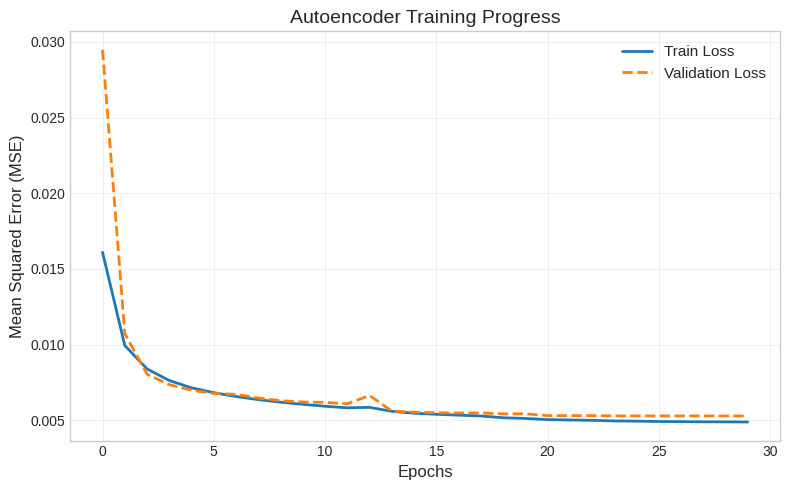

In [10]:
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Train Loss', linewidth=2)
plt.plot(history.history['val_loss'], label='Validation Loss', linewidth=2, linestyle='--')
plt.title('Autoencoder Training Progress', fontsize=14)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Squared Error (MSE)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Evaluating on unseen test data...
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step


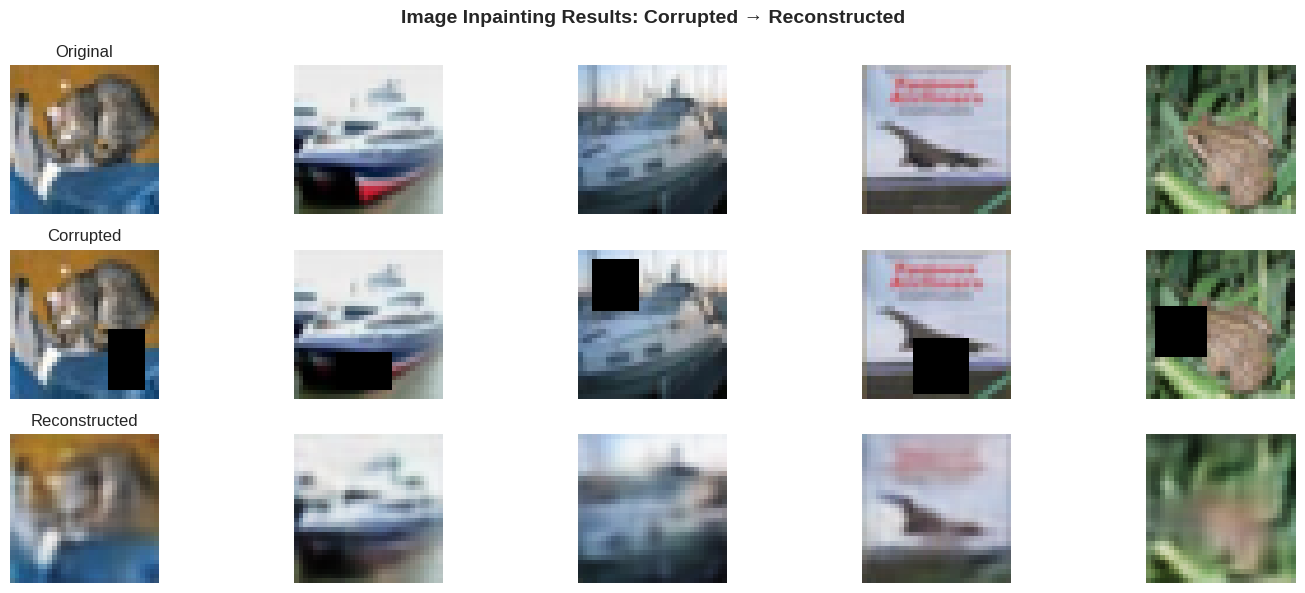

In [11]:
print("Evaluating on unseen test data...")
reconstructed = autoencoder.predict(x_test_corrupted)

# Visualize results
plot_comparison(x_test[:5], x_test_corrupted[:5], reconstructed[:5],
                title="Image Inpainting Results: Corrupted → Reconstructed")

In [12]:
# Define Hybrid Loss (MSE + SSIM)
def create_hybrid_loss(alpha=0.7):
    """
    Returns a Keras-compatible loss function combining MSE and SSIM.
    alpha: weight for MSE (0.7 = 70% pixel accuracy, 30% structural quality)
    """
    def loss(y_true, y_pred):
        # Pixel-wise accuracy
        mse = tf.reduce_mean(tf.square(y_true - y_pred))

        # Perceptual/structural similarity (1 - SSIM turns it into a minimization loss)
        ssim_val = tf.image.ssim(y_true, y_pred, max_val=1.0)
        ssim_loss = 1.0 - tf.reduce_mean(ssim_val)

        return alpha * mse + (1.0 - alpha) * ssim_loss
    return loss

In [13]:
#Compile with Hybrid Loss
hybrid_loss_fn = create_hybrid_loss(alpha=0.7)
autoencoder.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=hybrid_loss_fn
)

In [14]:
# Callbacks
early_stop = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=4, restore_best_weights=True, verbose=1)
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-5, verbose=1)

In [15]:
print("Training with Hybrid Loss (MSE + SSIM)...")
history = autoencoder.fit(
    x_train_corrupted, x_train,
    validation_split=0.1,
    epochs=30,
    batch_size=128,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

Training with Hybrid Loss (MSE + SSIM)...
Epoch 1/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 19s 31ms/step - loss: 0.0763 - val_loss: 0.0769 - learning_rate: 0.0010
Epoch 2/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - loss: 0.0733 - val_loss: 0.0750 - learning_rate: 0.0010
Epoch 3/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 0.0715 - val_loss: 0.0737 - learning_rate: 0.0010
Epoch 4/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0704 - val_loss: 0.0732 - learning_rate: 0.0010
Epoch 5/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0690 - val_loss: 0.0719 - learning_rate: 0.0010
Epoch 6/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.0680 - val_loss: 0.0714 - learning_rate: 0.0010
Epoch 7/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 0.0672 - val_loss: 0.0710 - learning_rate: 0.0010
Epoch 8/30
352/352 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 0.0666 - val_loss: 0.0713 - learning_rate: 0.0010
Epoch 9/30
349/352 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.0661


In [16]:
reconstructed = autoencoder.predict(x_test_corrupted)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step


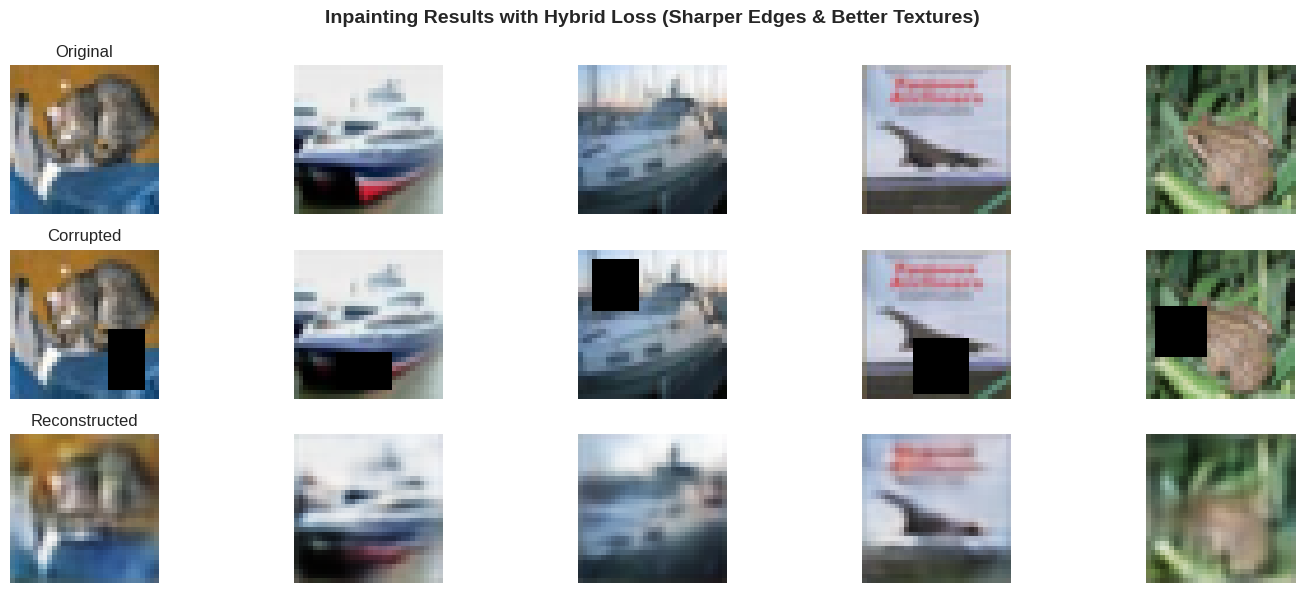

In [17]:
# Visualize results
plot_comparison(x_test[:5], x_test_corrupted[:5], reconstructed[:5],
                title="Inpainting Results with Hybrid Loss (Sharper Edges & Better Textures)")